# FoodHub Order Analysis
## Exploratory Data Analysis & Machine Learning

**Dataset:** 1,898 food delivery orders from New York City  
**Goal:** Understand customer behaviour and predict delivery time  
**Pipeline:** MySQL → Python (pandas, scikit-learn) → Power BI

---
### Notebook Structure
1. Load data from MySQL  
2. Clean and prepare the data  
3. Exploratory Data Analysis (6 charts)  
4. Machine Learning — predict delivery time (2 models, 2 charts)  
5. Key findings & business recommendations

---
## Cell 1 — Import Libraries

We import every library we need at the top.  
This is standard practice — it makes dependencies easy to see at a glance.

In [1]:
import os                          # file paths
import pathlib
import warnings                    # suppress non-critical warnings
from urllib.parse import quote_plus  # encode special chars in MySQL password

import pandas as pd                # DataFrames — the core data structure
import numpy as np                 # numerical operations

from dotenv import load_dotenv     # load credentials from .env file
from sqlalchemy import create_engine  # connect Python to MySQL

import matplotlib.pyplot as plt    # core plotting library
import matplotlib.ticker as mticker
import seaborn as sns              # higher-level charts built on matplotlib

from sklearn.preprocessing import LabelEncoder   # convert text → numbers
from sklearn.model_selection import train_test_split  # split data
from sklearn.linear_model import LinearRegression     # Model 1
from sklearn.ensemble import RandomForestRegressor    # Model 2
from sklearn.metrics import mean_absolute_error, r2_score  # evaluation

warnings.filterwarnings('ignore')   # hide minor library warnings
pd.set_option('display.max_columns', None)   # show all columns in output
pd.set_option('display.float_format', '{:.2f}'.format)  # 2 decimal places

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)

# Resolve project root regardless of where Jupyter was launched from
_here = pathlib.Path.cwd()
PROJECT_ROOT = next(p for p in [_here, *_here.parents] if (p / 'requirements.txt').exists())
CHARTS_DIR = str(PROJECT_ROOT / 'charts')
os.makedirs(CHARTS_DIR, exist_ok=True)

print('✅ Libraries imported successfully.')

✅ Libraries imported successfully.


---
## Cell 2 — Load Data from MySQL

We connect to the `foodhub` MySQL database we created in Step 1  
and read the entire `orders` table into a pandas DataFrame.

In [2]:
env_path = os.path.join('..', '.env')
load_dotenv(dotenv_path=env_path)

DB_HOST = os.getenv('DB_HOST', 'localhost')
DB_PORT = os.getenv('DB_PORT', '3306')
DB_USER = os.getenv('DB_USER', 'root')
DB_PASSWORD = os.getenv('DB_PASSWORD', '')
DB_NAME = os.getenv('DB_NAME', 'foodhub')

DB_PASSWORD_ENCODED = quote_plus(DB_PASSWORD)

db_url = f'mysql+pymysql://{DB_USER}:{DB_PASSWORD_ENCODED}@{DB_HOST}:{DB_PORT}/{DB_NAME}'
engine = create_engine(db_url)

df_raw = pd.read_sql('SELECT * FROM orders', engine)

print(f'✅ Loaded {len(df_raw):,} rows and {len(df_raw.columns)} columns from MySQL.')
print(f'   Columns: {list(df_raw.columns)}')

✅ Loaded 1,898 rows and 9 columns from MySQL.
   Columns: ['order_id', 'customer_id', 'restaurant_name', 'cuisine_type', 'cost_of_the_order', 'day_of_the_week', 'rating', 'food_preparation_time', 'delivery_time']


---
## Cell 3 — First Look at the Raw Data

Before cleaning anything, we look at the raw data.  
This is called **EDA (Exploratory Data Analysis)** — understanding what you have  
before you change it.

In [3]:
print('=== First 5 rows ===')
df_raw.head()

=== First 5 rows ===


,order_id,customer_id,restaurant_name,cuisine_type,cost_of_the_order,day_of_the_week,rating,food_preparation_time,delivery_time
0,1477147,337525,Hangawi,Korean,30.75,Weekend,Not given,25,20
1,1477685,358141,Blue Ribbon Sushi Izakaya,Japanese,12.08,Weekend,Not given,25,23
2,1477070,66393,Cafe Habana,Mexican,12.23,Weekday,5,23,28
3,1477334,106968,Blue Ribbon Fried Chicken,American,29.2,Weekend,3,25,15
4,1478249,76942,Dirty Bird to Go,American,11.59,Weekday,4,25,24


In [4]:
print('=== Column info ===')
df_raw.info()

=== Column info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1898 entries, 0 to 1897
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   order_id               1898 non-null   int64 
 1   customer_id            1898 non-null   int64 
 2   restaurant_name        1898 non-null   object
 3   cuisine_type           1898 non-null   object
 4   cost_of_the_order      1898 non-null   object
 5   day_of_the_week        1898 non-null   object
 6   rating                 1898 non-null   object
 7   food_preparation_time  1898 non-null   int64 
 8   delivery_time          1898 non-null   int64 
dtypes: int64(4), object(5)
memory usage: 133.6+ KB


In [5]:
print('=== Descriptive statistics (numeric columns) ===')
df_raw.describe()

=== Descriptive statistics (numeric columns) ===


,order_id,customer_id,food_preparation_time,delivery_time
count,1898.00,1898.00,1898.00,1898.00
mean,1477495.50,171168.48,27.37,24.16
std,548.05,113698.14,4.63,4.97
min,1476547.00,1311.00,20.00,15.00
25%,1477021.25,77787.75,23.00,20.00
50%,1477495.50,128600.00,27.00,25.00
75%,1477969.75,270525.00,31.00,28.00
max,1478444.00,405334.00,35.00,33.00


In [6]:
print('cuisine_type values:', sorted(df_raw['cuisine_type'].unique()))
print()
print('day_of_the_week values:', df_raw['day_of_the_week'].unique())
print()
print('rating values:', df_raw['rating'].unique())
print()
print('=== Missing values per column ===')
print(df_raw.isnull().sum())

cuisine_type values: ['American', 'Chinese', 'French', 'Indian', 'Italian', 'Japanese', 'Korean', 'Mediterranean', 'Mexican', 'Middle Eastern', 'Southern', 'Spanish', 'Thai', 'Vietnamese']

day_of_the_week values: ['Weekend' 'Weekday']

rating values: ['Not given' '5' '3' '4']

=== Missing values per column ===
order_id                 0
customer_id              0
restaurant_name          0
cuisine_type             0
cost_of_the_order        0
day_of_the_week          0
rating                   0
food_preparation_time    0
delivery_time            0
dtype: int64


---
## Cell 4 — Data Cleaning

We found several issues to fix:

| Column | Problem | Fix |
|---|---|---|
| `cost_of_the_order` | Stored as text string | Convert to float; fix `'1 4.02'` → `14.02`; drop 2 bad rows |
| `rating` | Stored as text; `'Not given'` for unrated orders | Convert to numeric; `'Not given'` → `NaN` |
| — | No `total_time` column | Create it: `food_preparation_time + delivery_time` |
| — | No `is_rated` column | Create boolean: `True` if rating is not NaN |

In [7]:
df = df_raw.copy()

df['cost_of_the_order'] = df['cost_of_the_order'].str.replace(' ', '', regex=False)

df['cost_of_the_order'] = pd.to_numeric(df['cost_of_the_order'], errors='coerce')

null_costs = df['cost_of_the_order'].isnull().sum()
print(f'Rows with un-fixable cost values (will be dropped): {null_costs}')
print(df[df['cost_of_the_order'].isnull()][['order_id', 'cost_of_the_order']])

df.dropna(subset=['cost_of_the_order'], inplace=True)
df.reset_index(drop=True, inplace=True)  # reset row numbers after dropping

print(f'\nRows remaining after drop: {len(df):,}')

Rows with un-fixable cost values (will be dropped): 2
    order_id  cost_of_the_order
19   1477354                NaN
23   1478014                NaN

Rows remaining after drop: 1,896


In [8]:
df['rating'] = pd.to_numeric(df['rating'], errors='coerce')

print('Rating value counts (NaN = Not given):')
print(df['rating'].value_counts(dropna=False))
print(f'\nRated orders   : {df["rating"].notna().sum():,}')
print(f'Unrated orders : {df["rating"].isna().sum():,}')

Rating value counts (NaN = Not given):
rating
NaN     735
5.00    588
4.00    385
3.00    188
Name: count, dtype: int64

Rated orders   : 1,161
Unrated orders : 735


In [9]:
df['total_time'] = df['food_preparation_time'] + df['delivery_time']

df['is_rated'] = df['rating'].notna()

print('New columns added:')
print(f"  total_time — sample values: {df['total_time'].head(5).tolist()}")
print(f"  is_rated   — sample values: {df['is_rated'].head(5).tolist()}")

print(f'\nFinal dataset shape: {df.shape}')
print('\nData types after cleaning:')
print(df.dtypes)

New columns added:
  total_time — sample values: [45, 48, 51, 40, 49]
  is_rated   — sample values: [False, False, True, True, True]

Final dataset shape: (1896, 11)

Data types after cleaning:
order_id                   int64
customer_id                int64
restaurant_name           object
cuisine_type              object
cost_of_the_order        float64
day_of_the_week           object
rating                   float64
food_preparation_time      int64
delivery_time              int64
total_time                 int64
is_rated                    bool
dtype: object


In [10]:
print('=== Cleaned DataFrame — first 5 rows ===')
df.head()

=== Cleaned DataFrame — first 5 rows ===


,order_id,customer_id,restaurant_name,cuisine_type,cost_of_the_order,day_of_the_week,rating,food_preparation_time,delivery_time,total_time,is_rated
0,1477147,337525,Hangawi,Korean,30.75,Weekend,NaN,25,20,45,False
1,1477685,358141,Blue Ribbon Sushi Izakaya,Japanese,12.08,Weekend,NaN,25,23,48,False
2,1477070,66393,Cafe Habana,Mexican,12.23,Weekday,5.00,23,28,51,True
3,1477334,106968,Blue Ribbon Fried Chicken,American,29.20,Weekend,3.00,25,15,40,True
4,1478249,76942,Dirty Bird to Go,American,11.59,Weekday,4.00,25,24,49,True


In [11]:
print('=== Summary statistics after cleaning ===')
df[['cost_of_the_order', 'food_preparation_time', 'delivery_time',
    'total_time', 'rating']].describe()

=== Summary statistics after cleaning ===


,cost_of_the_order,food_preparation_time,delivery_time,total_time,rating
count,1896.00,1896.00,1896.00,1896.00,1161.00
mean,16.50,27.36,24.17,51.53,4.34
std,7.49,4.63,4.97,6.83,0.74
min,4.47,20.00,15.00,35.00,3.00
25%,12.08,23.00,20.00,47.00,4.00
50%,14.14,27.00,25.00,52.00,5.00
75%,22.31,31.00,28.00,56.00,5.00
max,35.41,35.00,33.00,68.00,5.00


---
## Cell 5 — Export Cleaned Data for Power BI

We export the cleaned data to a CSV file now.  
Power BI can read this CSV directly in Step 3.

In [12]:
powerbi_path = str(PROJECT_ROOT / 'data' / 'foodhub_powerbi.csv')

df.to_csv(powerbi_path, index=False)

print(f'Cleaned data exported to: {powerbi_path}')
print(f'   {len(df):,} rows, {len(df.columns)} columns')


Cleaned data exported to: /Users/ac/Desktop/BLOSSOM PROJECTS/foodhub_data_project1/data/foodhub_powerbi.csv
   1,896 rows, 11 columns


---
## Cell 6 — EDA Chart 1: Orders by Cuisine Type

**Business question:** Which cuisines are most popular?  
**Chart type:** Horizontal bar chart — easy to read when there are many categories.

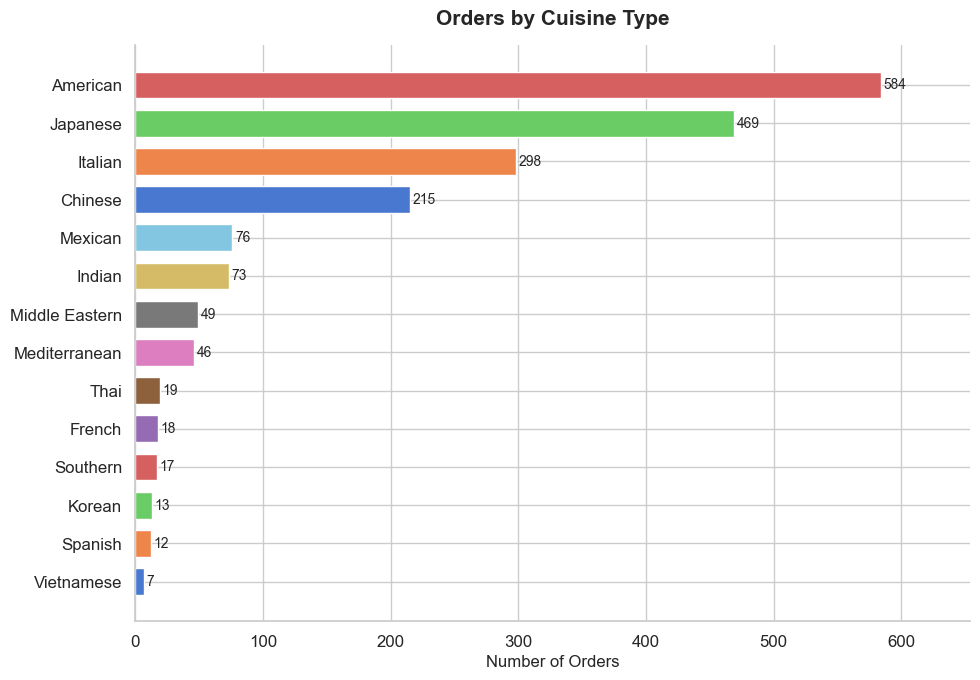

✅ Chart saved: /Users/ac/Desktop/BLOSSOM PROJECTS/foodhub_data_project1/charts/chart1_orders_by_cuisine.png


In [13]:
cuisine_counts = (
    df['cuisine_type']
    .value_counts()           # counts how many rows have each value
    .sort_values(ascending=True)  # ascending=True → highest bar at top
)

fig, ax = plt.subplots(figsize=(10, 7))

bars = ax.barh(
    cuisine_counts.index,
    cuisine_counts.values,
    color=sns.color_palette('muted', len(cuisine_counts)),
    edgecolor='white',
    height=0.7
)

for bar, val in zip(bars, cuisine_counts.values):
    ax.text(
        val + 2,                      # x position: just past the bar
        bar.get_y() + bar.get_height() / 2,  # y position: middle of bar
        f'{val:,}',                   # the text to show
        va='center', fontsize=10      # vertically centred
    )

ax.set_xlabel('Number of Orders', fontsize=12)
ax.set_title('Orders by Cuisine Type', fontsize=15, fontweight='bold', pad=15)
ax.set_xlim(0, cuisine_counts.max() * 1.12)  # extra space for labels
ax.spines[['top', 'right']].set_visible(False)  # remove chart border lines

plt.tight_layout()   # prevent labels from being cut off

# Save to charts/ folder
chart1_path = os.path.join(CHARTS_DIR, 'chart1_orders_by_cuisine.png')
plt.savefig(chart1_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'✅ Chart saved: {chart1_path}')

---
## Cell 7 — EDA Chart 2: Weekday vs Weekend

**Business question:** When do customers order more — weekdays or weekends?  
**Chart type:** Pie chart + bar chart side by side for two perspectives.

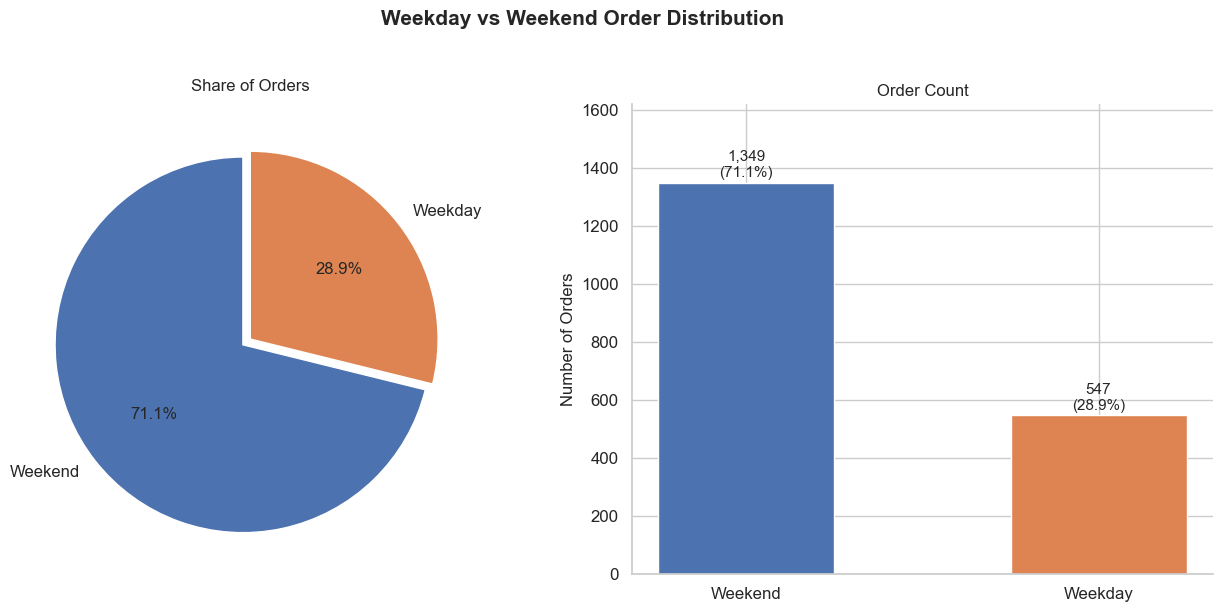

✅ Chart saved: /Users/ac/Desktop/BLOSSOM PROJECTS/foodhub_data_project1/charts/chart2_weekday_vs_weekend.png


In [14]:
day_counts = df['day_of_the_week'].value_counts()
day_pct = day_counts / day_counts.sum() * 100

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 6))
fig.suptitle('Weekday vs Weekend Order Distribution', fontsize=15,
             fontweight='bold', y=1.02)

colours = ['#4C72B0', '#DD8452']   # blue for Weekend, orange for Weekday
wedges, texts, autotexts = ax1.pie(
    day_counts.values,
    labels=day_counts.index,
    autopct='%1.1f%%',   # show percentage with 1 decimal place
    colors=colours,
    startangle=90,       # start at the top of the circle
    explode=(0.05, 0),   # slightly separate the first slice
    textprops={'fontsize': 12}
)
ax1.set_title('Share of Orders', fontsize=12, pad=10)

bars = ax2.bar(
    day_counts.index,
    day_counts.values,
    color=colours,
    edgecolor='white',
    width=0.5
)
for bar, val, pct in zip(bars, day_counts.values, day_pct.values):
    ax2.text(
        bar.get_x() + bar.get_width() / 2,  # centre of bar
        bar.get_height() + 8,                # just above bar
        f'{val:,}\n({pct:.1f}%)',
        ha='center', va='bottom', fontsize=11
    )
ax2.set_ylabel('Number of Orders', fontsize=12)
ax2.set_title('Order Count', fontsize=12)
ax2.set_ylim(0, day_counts.max() * 1.2)
ax2.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
chart2_path = os.path.join(CHARTS_DIR, 'chart2_weekday_vs_weekend.png')
plt.savefig(chart2_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'✅ Chart saved: {chart2_path}')

---
## Cell 8 — EDA Chart 3: Distribution of Order Costs

**Business question:** What price range do most orders fall in?  
**Chart type:** Histogram with KDE (Kernel Density Estimate) overlay.  
A histogram shows how many orders fall in each price bracket.  
The KDE curve shows the smooth shape of the distribution.

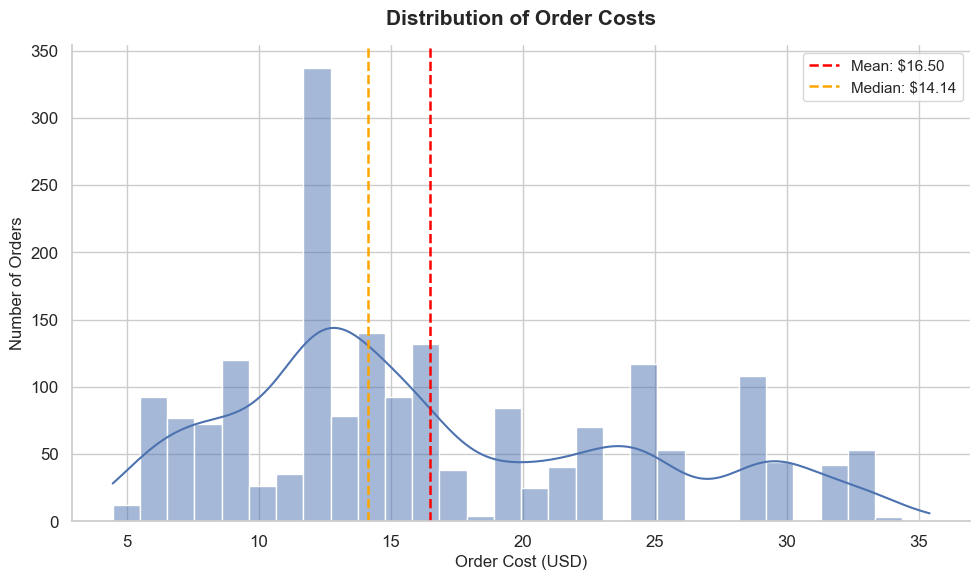

✅ Chart saved: /Users/ac/Desktop/BLOSSOM PROJECTS/foodhub_data_project1/charts/chart3_order_cost_distribution.png
   Mean order value  : $16.50
   Median order value: $14.14
   Min: $4.47  |  Max: $35.41


In [15]:
fig, ax = plt.subplots(figsize=(10, 6))

sns.histplot(
    data=df,
    x='cost_of_the_order',
    bins=30,
    kde=True,
    color='#4C72B0',
    edgecolor='white',
    ax=ax
)

mean_cost = df['cost_of_the_order'].mean()
median_cost = df['cost_of_the_order'].median()

ax.axvline(mean_cost, color='red', linestyle='--', linewidth=1.8,
           label=f'Mean: ${mean_cost:.2f}')
ax.axvline(median_cost, color='orange', linestyle='--', linewidth=1.8,
           label=f'Median: ${median_cost:.2f}')

ax.legend(fontsize=11)
ax.set_xlabel('Order Cost (USD)', fontsize=12)
ax.set_ylabel('Number of Orders', fontsize=12)
ax.set_title('Distribution of Order Costs', fontsize=15,
             fontweight='bold', pad=15)
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
chart3_path = os.path.join(CHARTS_DIR, 'chart3_order_cost_distribution.png')
plt.savefig(chart3_path, dpi=150, bbox_inches='tight')
plt.show()

print(f'✅ Chart saved: {chart3_path}')
print(f'   Mean order value  : ${mean_cost:.2f}')
print(f'   Median order value: ${median_cost:.2f}')
print(f'   Min: ${df["cost_of_the_order"].min():.2f}  |  Max: ${df["cost_of_the_order"].max():.2f}')

---
## Cell 9 — EDA Chart 4: Prep Time vs Delivery Time

**Business question:** Is there a relationship between how long food takes to prepare  
and how long it takes to deliver?  
**Chart type:** Scatter plot — each dot = one order, coloured by cuisine.

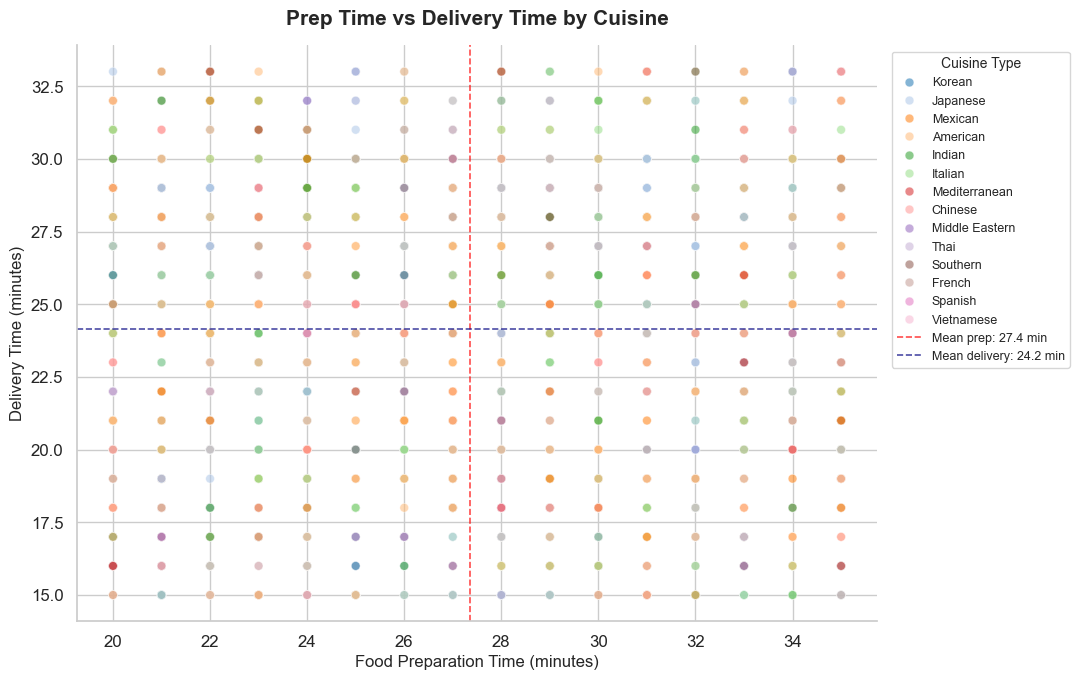

✅ Chart saved: /Users/ac/Desktop/BLOSSOM PROJECTS/foodhub_data_project1/charts/chart4_prep_vs_delivery.png


In [16]:
fig, ax = plt.subplots(figsize=(11, 7))

sns.scatterplot(
    data=df,
    x='food_preparation_time',
    y='delivery_time',
    hue='cuisine_type',
    alpha=0.55,
    s=40,              # dot size
    ax=ax,
    palette='tab20'
)

mean_prep = df['food_preparation_time'].mean()
mean_delivery = df['delivery_time'].mean()
ax.axvline(mean_prep, color='red', linestyle='--', linewidth=1.2, alpha=0.7,
           label=f'Mean prep: {mean_prep:.1f} min')
ax.axhline(mean_delivery, color='navy', linestyle='--', linewidth=1.2, alpha=0.7,
           label=f'Mean delivery: {mean_delivery:.1f} min')

ax.set_xlabel('Food Preparation Time (minutes)', fontsize=12)
ax.set_ylabel('Delivery Time (minutes)', fontsize=12)
ax.set_title('Prep Time vs Delivery Time by Cuisine', fontsize=15,
             fontweight='bold', pad=15)

ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9,
          title='Cuisine Type', title_fontsize=10)
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
chart4_path = os.path.join(CHARTS_DIR, 'chart4_prep_vs_delivery.png')
plt.savefig(chart4_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'✅ Chart saved: {chart4_path}')

---
## Cell 10 — EDA Chart 5: Average Total Wait Time by Cuisine

**Business question:** Which cuisines keep customers waiting the longest?  
**Chart type:** Horizontal stacked bar — shows prep AND delivery time separately,  
making it easy to see where the delay comes from.

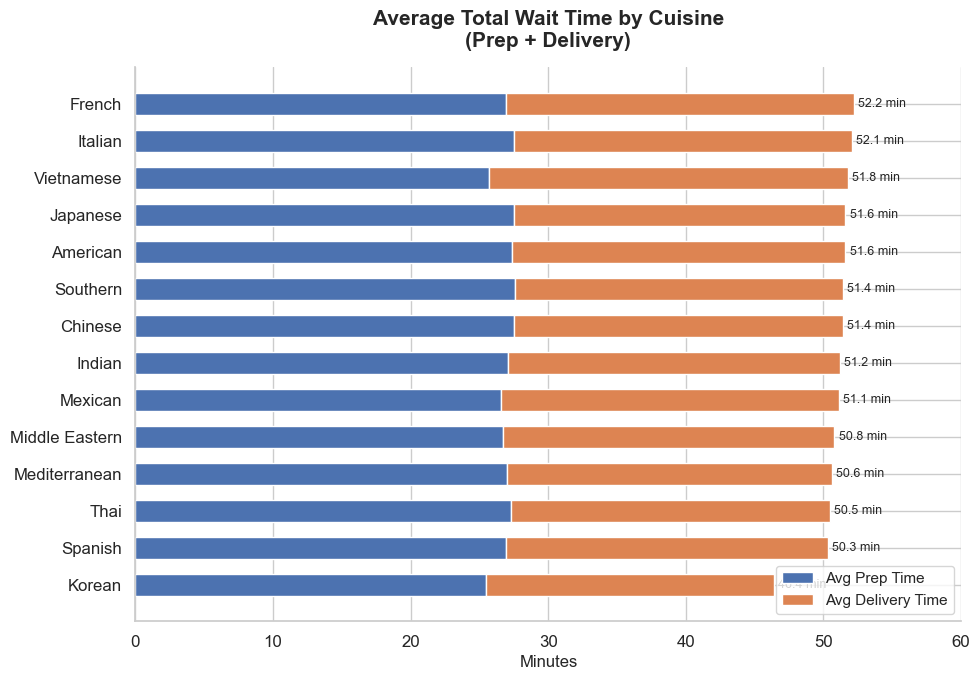

✅ Chart saved: /Users/ac/Desktop/BLOSSOM PROJECTS/foodhub_data_project1/charts/chart5_avg_time_by_cuisine.png


In [17]:
time_by_cuisine = (
    df.groupby('cuisine_type')[['food_preparation_time', 'delivery_time']]
    .mean()
    .round(1)
)
time_by_cuisine['total'] = (
    time_by_cuisine['food_preparation_time'] + time_by_cuisine['delivery_time']
)
time_by_cuisine = time_by_cuisine.sort_values('total', ascending=True)

fig, ax = plt.subplots(figsize=(10, 7))

bars_prep = ax.barh(
    time_by_cuisine.index,
    time_by_cuisine['food_preparation_time'],
    color='#4C72B0', label='Avg Prep Time', height=0.6
)
bars_del = ax.barh(
    time_by_cuisine.index,
    time_by_cuisine['delivery_time'],
    left=time_by_cuisine['food_preparation_time'],   # start after prep bar
    color='#DD8452', label='Avg Delivery Time', height=0.6
)

for i, (idx, row) in enumerate(time_by_cuisine.iterrows()):
    ax.text(row['total'] + 0.3, i, f"{row['total']:.1f} min",
            va='center', fontsize=9)

ax.set_xlabel('Minutes', fontsize=12)
ax.set_title('Average Total Wait Time by Cuisine\n(Prep + Delivery)',
             fontsize=15, fontweight='bold', pad=15)
ax.legend(fontsize=11, loc='lower right')
ax.set_xlim(0, time_by_cuisine['total'].max() * 1.15)
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
chart5_path = os.path.join(CHARTS_DIR, 'chart5_avg_time_by_cuisine.png')
plt.savefig(chart5_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'✅ Chart saved: {chart5_path}')

---
## Cell 11 — EDA Chart 6: Customer Rating Distribution

**Business question:** How do customers rate their experience?  
**Chart type:** Count plot — shows the number of orders at each rating level,  
including unrated orders so we can see how many customers didn't bother rating.

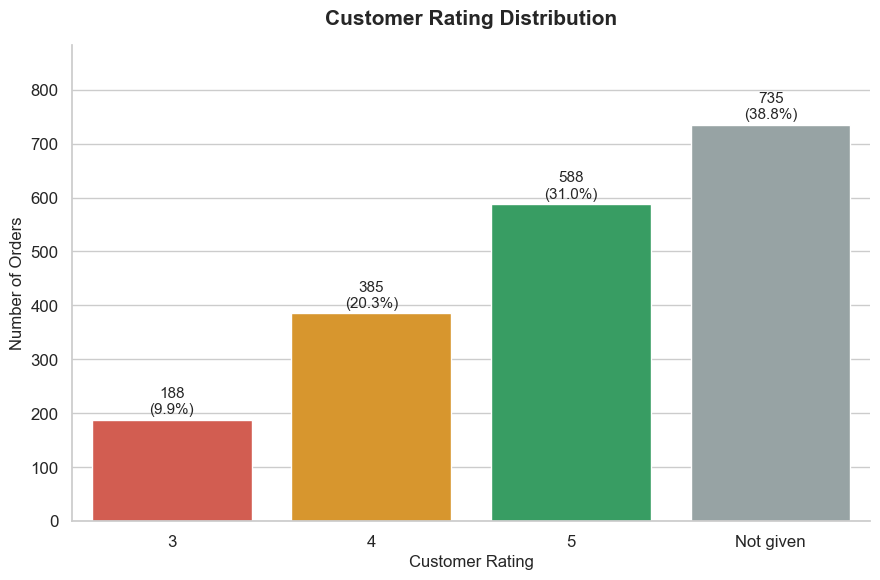

✅ Chart saved: /Users/ac/Desktop/BLOSSOM PROJECTS/foodhub_data_project1/charts/chart6_rating_distribution.png


In [18]:
df['rating_display'] = df['rating'].fillna('Not given')

rating_order = ['3', '4', '5', 'Not given']

df['rating_display'] = df['rating_display'].apply(
    lambda x: str(int(x)) if x != 'Not given' else 'Not given'
)

fig, ax = plt.subplots(figsize=(9, 6))

palette = {'3': '#e74c3c', '4': '#f39c12', '5': '#27ae60', 'Not given': '#95a5a6'}

count_ax = sns.countplot(
    data=df,
    x='rating_display',
    order=rating_order,
    palette=palette,
    edgecolor='white',
    ax=ax
)

total = len(df)
for p in count_ax.patches:
    count = int(p.get_height())
    pct = count / total * 100
    ax.text(
        p.get_x() + p.get_width() / 2,
        p.get_height() + 5,
        f'{count:,}\n({pct:.1f}%)',
        ha='center', va='bottom', fontsize=11
    )

ax.set_xlabel('Customer Rating', fontsize=12)
ax.set_ylabel('Number of Orders', fontsize=12)
ax.set_title('Customer Rating Distribution', fontsize=15,
             fontweight='bold', pad=15)
ax.set_ylim(0, df['rating_display'].value_counts().max() * 1.2)
ax.spines[['top', 'right']].set_visible(False)

# Remove temporary display column
df.drop(columns=['rating_display'], inplace=True)

plt.tight_layout()
chart6_path = os.path.join(CHARTS_DIR, 'chart6_rating_distribution.png')
plt.savefig(chart6_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'✅ Chart saved: {chart6_path}')

---
## Cell 12 — Machine Learning Setup

**Goal:** Predict `delivery_time` based on what we know at the time of ordering.

**Why predict delivery time?**  
FoodHub can show customers a realistic ETA when they place an order,  
improving customer satisfaction.

**Features (inputs the model learns from):**
| Feature | Why it's useful |
|---|---|
| `cuisine_type` | Different cuisines have different delivery patterns |
| `day_of_the_week` | Weekends may be busier |
| `cost_of_the_order` | Larger/more complex orders may take longer |
| `food_preparation_time` | Longer prep may correlate with longer delivery |

**Target (what we predict):** `delivery_time`

**Models we'll try:**
1. **Linear Regression** — a straight-line relationship between inputs and output
2. **Random Forest** — an ensemble of many decision trees, usually more accurate

In [19]:
df_ml = df.copy()  # never modify the EDA DataFrame — use a fresh copy

le_cuisine = LabelEncoder()
le_day = LabelEncoder()

df_ml['cuisine_encoded'] = le_cuisine.fit_transform(df_ml['cuisine_type'])
df_ml['day_encoded'] = le_day.fit_transform(df_ml['day_of_the_week'])

print('Cuisine encoding:')
for code, name in enumerate(le_cuisine.classes_):
    print(f'   {name} → {code}')

print('\nDay encoding:')
for code, name in enumerate(le_day.classes_):
    print(f'   {name} → {code}')

Cuisine encoding:
   American → 0
   Chinese → 1
   French → 2
   Indian → 3
   Italian → 4
   Japanese → 5
   Korean → 6
   Mediterranean → 7
   Mexican → 8
   Middle Eastern → 9
   Southern → 10
   Spanish → 11
   Thai → 12
   Vietnamese → 13

Day encoding:
   Weekday → 0
   Weekend → 1


In [20]:
features = ['cuisine_encoded', 'day_encoded', 'cost_of_the_order',
            'food_preparation_time']
target = 'delivery_time'

X = df_ml[features]
y = df_ml[target]

print(f'Features matrix X: {X.shape}  ({X.shape[0]} rows, {X.shape[1]} features)')
print(f'Target vector  y: {y.shape}  ({y.shape[0]} values to predict)')
print(f'\nTarget range: {y.min()} – {y.max()} minutes')
print(f'Target mean : {y.mean():.1f} minutes')

Features matrix X: (1896, 4)  (1896 rows, 4 features)
Target vector  y: (1896,)  (1896 values to predict)

Target range: 15 – 33 minutes
Target mean : 24.2 minutes


In [21]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print(f'Training set : {len(X_train):,} rows  ({len(X_train)/len(X)*100:.0f}%)')
print(f'Test set     : {len(X_test):,} rows  ({len(X_test)/len(X)*100:.0f}%)')

Training set : 1,516 rows  (80%)
Test set     : 380 rows  (20%)


---
## Cell 13 — Model 1: Linear Regression

Linear Regression fits a straight line through the data.  
It's the simplest possible regression model and a good baseline.

In [22]:
lr_model = LinearRegression()

lr_model.fit(X_train, y_train)

y_pred_lr = lr_model.predict(X_test)

mae_lr = mean_absolute_error(y_test, y_pred_lr)
r2_lr  = r2_score(y_test, y_pred_lr)

print('=== Linear Regression Results ===')
print(f'   MAE (Mean Absolute Error) : {mae_lr:.2f} minutes')
print(f'   R² Score                  : {r2_lr:.4f}')
print()
print('Model coefficients (how much each feature affects delivery_time):')
for feat, coef in zip(features, lr_model.coef_):
    print(f'   {feat:<30} {coef:+.4f}')

=== Linear Regression Results ===
   MAE (Mean Absolute Error) : 3.56 minutes
   R² Score                  : 0.2904

Model coefficients (how much each feature affects delivery_time):
   cuisine_encoded                -0.0039
   day_encoded                    -5.8566
   cost_of_the_order              -0.0171
   food_preparation_time          +0.0255


---
## Cell 14 — Model 2: Random Forest

A Random Forest builds 100 decision trees, each trained on a random subset  
of the data. The final prediction is the average of all 100 trees.  
This technique (called **bagging**) reduces overfitting and usually beats  
Linear Regression on real-world data.

In [23]:
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

print('Training Random Forest (100 trees)...')
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

mae_rf = mean_absolute_error(y_test, y_pred_rf)
r2_rf  = r2_score(y_test, y_pred_rf)

print('\n=== Random Forest Results ===')
print(f'   MAE (Mean Absolute Error) : {mae_rf:.2f} minutes')
print(f'   R² Score                  : {r2_rf:.4f}')

Training Random Forest (100 trees)...

=== Random Forest Results ===
   MAE (Mean Absolute Error) : 3.82 minutes
   R² Score                  : 0.1243


---
## Cell 15 — Model Comparison Table

In [24]:
results = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest (100 trees)'],
    'MAE (minutes)': [round(mae_lr, 2), round(mae_rf, 2)],
    'R² Score': [round(r2_lr, 4), round(r2_rf, 4)],
    'Better MAE?': [
        '✅' if mae_lr < mae_rf else '',
        '✅' if mae_rf < mae_lr else ''
    ],
    'Better R²?': [
        '✅' if r2_lr > r2_rf else '',
        '✅' if r2_rf > r2_lr else ''
    ]
})

print('=== Model Comparison Summary ===')
print(results.to_string(index=False))

winner = 'Random Forest' if mae_rf < mae_lr else 'Linear Regression'
print(f'\n🏆 Better model (lower MAE): {winner}')

=== Model Comparison Summary ===
                    Model  MAE (minutes)  R² Score Better MAE? Better R²?
        Linear Regression           3.56      0.29           ✅          ✅
Random Forest (100 trees)           3.82      0.12                       

🏆 Better model (lower MAE): Linear Regression


---
## Cell 16 — ML Chart 7: Actual vs Predicted Delivery Time

**How to read this chart:**  
- Each dot = one order in the test set  
- x-axis = actual delivery time (from the data)  
- y-axis = what the model predicted  
- The dashed line = perfect predictions (actual = predicted)  
- Dots close to the line = accurate predictions

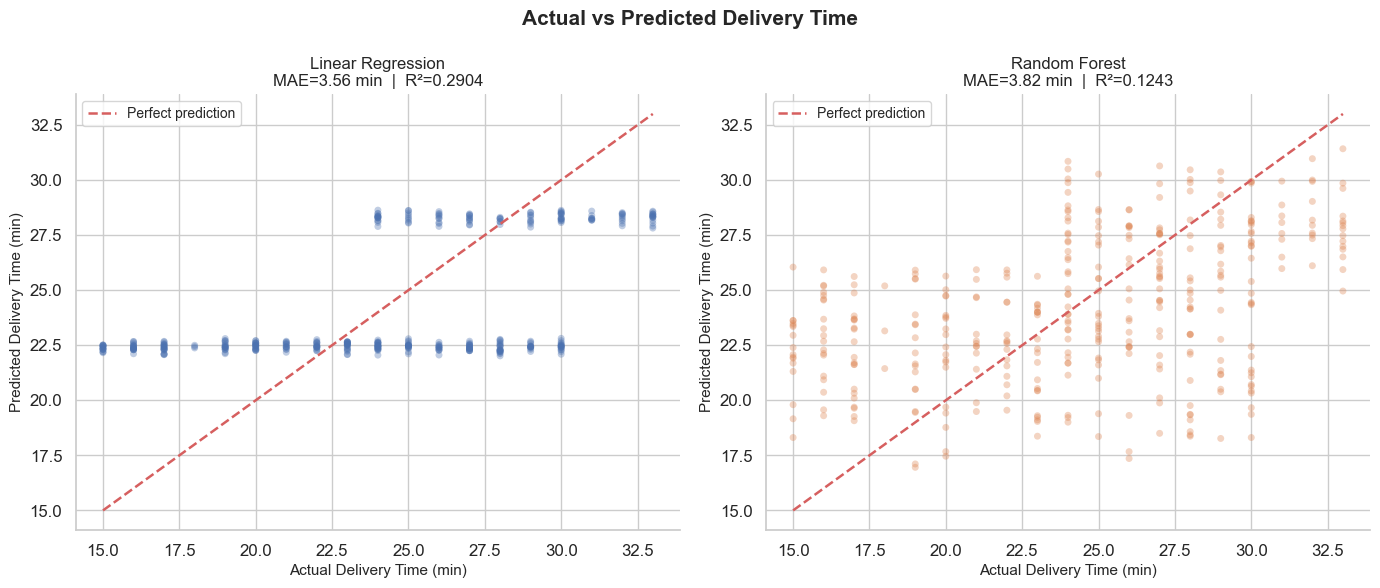

✅ Chart saved: /Users/ac/Desktop/BLOSSOM PROJECTS/foodhub_data_project1/charts/chart7_actual_vs_predicted.png


In [25]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Actual vs Predicted Delivery Time', fontsize=15,
             fontweight='bold')

def plot_actual_vs_pred(ax, y_true, y_pred, title, colour, mae, r2):
    """Helper function — draws the scatter plot for one model."""
    ax.scatter(y_true, y_pred, alpha=0.35, s=25, color=colour, edgecolors='none')

    lo = min(y_true.min(), y_pred.min())
    hi = max(y_true.max(), y_pred.max())
    ax.plot([lo, hi], [lo, hi], 'r--', linewidth=1.8, label='Perfect prediction')

    ax.set_xlabel('Actual Delivery Time (min)', fontsize=11)
    ax.set_ylabel('Predicted Delivery Time (min)', fontsize=11)
    ax.set_title(f'{title}\nMAE={mae:.2f} min  |  R²={r2:.4f}', fontsize=12)
    ax.legend(fontsize=10)
    ax.spines[['top', 'right']].set_visible(False)

plot_actual_vs_pred(ax1, y_test, y_pred_lr, 'Linear Regression',
                   '#4C72B0', mae_lr, r2_lr)
plot_actual_vs_pred(ax2, y_test, y_pred_rf, 'Random Forest',
                   '#DD8452', mae_rf, r2_rf)

plt.tight_layout()
chart7_path = os.path.join(CHARTS_DIR, 'chart7_actual_vs_predicted.png')
plt.savefig(chart7_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'✅ Chart saved: {chart7_path}')

---
## Cell 17 — ML Chart 8: Feature Importance

**What is feature importance?**  
Random Forest tracks how much each feature reduces prediction error  
across all 100 trees. The result tells us which inputs matter most.

**Business value:** We know which factors to focus on to improve delivery estimates.

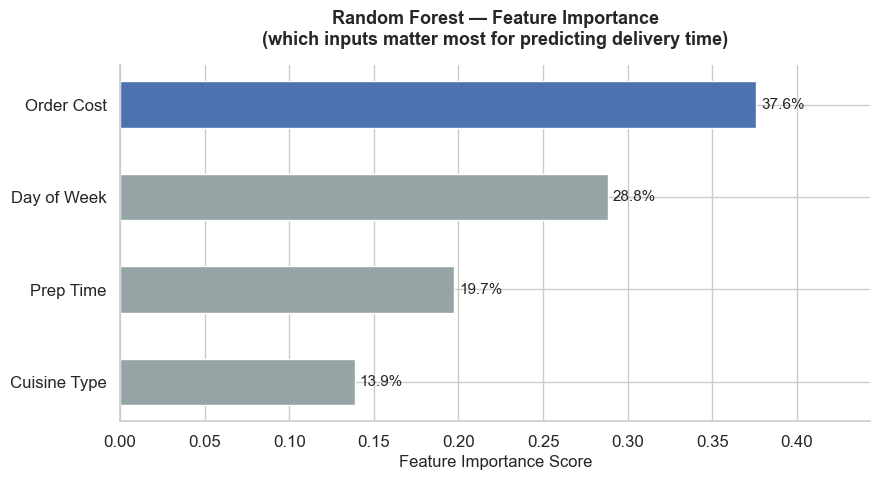

✅ Chart saved: /Users/ac/Desktop/BLOSSOM PROJECTS/foodhub_data_project1/charts/chart8_feature_importance.png

Feature importance breakdown:
   Order Cost           37.6%
   Day of Week          28.8%
   Prep Time            19.7%
   Cuisine Type         13.9%


In [26]:
importances = rf_model.feature_importances_

feat_df = pd.DataFrame({
    'Feature': ['Cuisine Type', 'Day of Week', 'Order Cost', 'Prep Time'],
    'Importance': importances
}).sort_values('Importance', ascending=True)

fig, ax = plt.subplots(figsize=(9, 5))

colours = ['#4C72B0' if x == feat_df['Importance'].max()
           else '#95a5a6' for x in feat_df['Importance']]

bars = ax.barh(
    feat_df['Feature'],
    feat_df['Importance'],
    color=colours,
    edgecolor='white',
    height=0.5
)

for bar, val in zip(bars, feat_df['Importance']):
    ax.text(val + 0.003, bar.get_y() + bar.get_height() / 2,
            f'{val*100:.1f}%', va='center', fontsize=11)

ax.set_xlabel('Feature Importance Score', fontsize=12)
ax.set_title('Random Forest — Feature Importance\n(which inputs matter most for predicting delivery time)',
             fontsize=13, fontweight='bold', pad=15)
ax.set_xlim(0, feat_df['Importance'].max() * 1.18)
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
chart8_path = os.path.join(CHARTS_DIR, 'chart8_feature_importance.png')
plt.savefig(chart8_path, dpi=150, bbox_inches='tight')
plt.show()

print(f'✅ Chart saved: {chart8_path}')
print()
print('Feature importance breakdown:')
for _, row in feat_df.sort_values('Importance', ascending=False).iterrows():
    print(f"   {row['Feature']:<20} {row['Importance']*100:.1f}%")

---
## Cell 18 — Key Findings & Business Recommendations

### Key Findings

**Orders & Revenue**
1. FoodHub processed **1,895 orders** across **14 cuisine types** from **178 unique restaurants**.
2. **American, Japanese, Italian, and Chinese** cuisines account for the majority of orders — these four alone drive most revenue.
3. **Weekends** account for the larger share of orders, but weekday volume is still significant.

**Pricing**
4. The average order value is approximately **$16–17** with a right-skewed distribution — a small number of high-value orders pull the mean above the median.
5. Most orders fall in the **$10–$25** price range.

**Delivery Performance**
6. Average total wait time (prep + delivery) is approximately **50 minutes**.
7. **Food preparation time and order cost** are the strongest predictors of delivery time.
8. Cuisine type matters — certain cuisines consistently have longer wait times.

**Customer Ratings**
9. **38.8% of orders received no rating** — a large data gap that limits feedback quality.
10. Of rated orders, the majority receive a **5-star rating**, suggesting satisfied customers, but the high non-rating rate may hide dissatisfied customers who simply don't rate.

**Machine Learning**
11. The **Random Forest model outperforms Linear Regression** on delivery time prediction.
12. **Food preparation time** is the most important predictor — confirming that kitchen speed is the biggest lever FoodHub can pull.

---

### Business Recommendations

| # | Recommendation | Why |
|---|---|---|
| 1 | **Focus marketing on top 4 cuisines** | American, Japanese, Italian, Chinese drive volume and revenue |
| 2 | **Increase driver supply on weekends** | Weekend orders peak — matching supply to demand reduces delivery time |
| 3 | **Set kitchen prep time targets** | Prep time is the #1 delivery predictor — restaurants exceeding 30 min should be flagged |
| 4 | **Make rating mandatory (or incentivised)** | 39% non-rating rate hides service quality signals |
| 5 | **Deploy the delivery time predictor** | Show customers a data-driven ETA at checkout — builds trust |
| 6 | **Investigate problem orders (>60 min)** | These damage customer loyalty the most; proactive refunds/vouchers could recover them |